In [4]:
import numpy as np
import os
import torchvision.transforms.functional as TF
import json
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import AutoImageProcessor, ZoeDepthForDepthEstimation

In [1]:
# Path to COCO dataset
COCO_PATH = "/kaggle/input/mmsample"

# Load COCO annotations
def load_coco_annotations(annotation_file):
    with open(annotation_file, 'r') as f:
        annotations = json.load(f)
    return annotations

# Load COCO train annotations
train_annotation_path = os.path.join(COCO_PATH, "annotations", "instances_train2017.json")
coco_train_annotations = load_coco_annotations(train_annotation_path)

# Get image ID and bounding boxes
def get_image_annotations(image_id, annotations):
    image_data = None
    for img in annotations["images"]:
        if img["id"] == image_id:
            image_data = img
            break

    if image_data is None:
        return None, None

    bboxes = []
    labels = []
    for ann in annotations["annotations"]:
        if ann["image_id"] == image_id:
            x, y, w, h = ann["bbox"]
            bboxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

    return image_data, bboxes, labels

# Select a random image from the annotation (instead of always the first)
all_images = coco_train_annotations["images"]
random_image = random.choice(all_images)
image_id = random_image["id"]

# Retrieve bounding boxes + labels for this image
image_data, bboxes, labels = get_image_annotations(image_id, coco_train_annotations)

if image_data is None:
    print("No image found with this ID.")
else:
    # Load the actual image from 'train2017' folder
    image_path = os.path.join(COCO_PATH, "train2017", image_data["file_name"])
    image = Image.open(image_path).convert("RGB")

    # Draw bounding boxes
    draw = ImageDraw.Draw(image)
    for box in bboxes:
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

    # Display image with bounding boxes
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Object Detection")
    plt.show()

NameError: name 'os' is not defined

In [105]:
# Root folder on Kaggle for your dataset
COCO_PATH = "/kaggle/input/mmsample"

# Paths to the annotations
train_annotation_path = os.path.join(COCO_PATH, "annotations", "instances_train2017.json")
val_annotation_path   = os.path.join(COCO_PATH, "annotations", "instances_val2017.json")

# Path to the train images
train_image_dir = os.path.join(COCO_PATH, "train2017")

print("Train annotation file:", train_annotation_path)
print("Val annotation file:", val_annotation_path)
print("Train images folder:", train_image_dir)

Train annotation file: /kaggle/input/mmsample/annotations/instances_train2017.json
Val annotation file: /kaggle/input/mmsample/annotations/instances_val2017.json
Train images folder: /kaggle/input/mmsample/train2017


In [5]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_dataset = CocoDetection(
    root=train_image_dir,
    annFile=train_annotation_path,
    transform=transform
)

NameError: name 'train_image_dir' is not defined

In [107]:
COCO_PATH = "/kaggle/input/mmsample"

# Images and Annotations
image_dir = os.path.join(COCO_PATH, "train2017")  # e.g., /kaggle/input/mmsample/train2017
annotation_file = os.path.join(COCO_PATH, "annotations", "instances_train2017.json")

all_image_files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
n_images = len(all_image_files)
print("Total images found:", n_images)

# If dataset is very small, skip splitting
if n_images < 2:
    train_imgs = all_image_files
    val_imgs = []
else:
    train_imgs, val_imgs = train_test_split(all_image_files, test_size=0.1, random_state=42)

print(f"Train images: {len(train_imgs)}, Validation images: {len(val_imgs)}")

# Single-Object Dataset with cat2idx Mapping

class CoCoSingleObjectDataset(Dataset):
    """
    A wrapper around torchvision.datasets.CocoDetection that:
      - Resizes images to a fixed size (e.g., 128x128)
      - Scales bounding boxes accordingly
      - Uses only the first annotation per image (for a single-object detection model)
      - Maps COCO category_id to a contiguous range [0..79] with cat2idx
    """
    def __init__(self, image_paths, annFile, transform=None, input_size=128):
        """
        image_paths: list of image file paths (train or val split)
        annFile: path to instances_train2017.json
        transform: resize, toTensor, etc.
        input_size: assumed final image size for bounding box scaling
        """
        super().__init__()
        self.image_paths = image_paths
        self.transform = transform
        self.input_size = input_size
        
        # Use CocoDetection to parse JSON annotations
        self.coco_dataset = datasets.CocoDetection(
            root=os.path.dirname(image_paths[0]) if image_paths else image_dir,  
            annFile=annFile,
            transform=None  # We'll apply transform manually
        )

        # Build a file_name -> image_id map
        self.file_to_id = {}
        for img_info in self.coco_dataset.coco.imgs.values():
            self.file_to_id[img_info["file_name"]] = img_info["id"]

        # Build category ID -> index mapping (cat2idx)
        cat_ids = sorted(self.coco_dataset.coco.getCatIds())
        self.cat2idx = {cat_id: idx for idx, cat_id in enumerate(cat_ids)}

        print("Number of unique category IDs in dataset:", len(cat_ids))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        if idx >= len(self.image_paths):
            raise IndexError("Index out of range for dataset.")

        img_path = self.image_paths[idx]
        file_name = os.path.basename(img_path)

        # If the file_name not in self.file_to_id, we have no annotation => dummy
        if file_name not in self.file_to_id:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, torch.zeros((1,4)), torch.zeros((1,), dtype=torch.long)

        image_id = self.file_to_id[file_name]
        ann_list = self.coco_dataset.coco.loadAnns(
            self.coco_dataset.coco.getAnnIds(imgIds=image_id)
        )
        image = Image.open(img_path).convert("RGB")

        # If no annotation, return dummy
        if len(ann_list) == 0:
            if self.transform:
                image = self.transform(image)
            return image, torch.zeros((1,4)), torch.zeros((1,), dtype=torch.long)

        # Take the first annotation
        ann = ann_list[0]
        bbox = ann["bbox"]  # [x, y, w, h] in original coordinates
        cat_id = ann["category_id"]
        
        # Map cat_id to a 0-based index
        if cat_id not in self.cat2idx:
            # If we find a cat_id not in cat2idx, treat as background or clamp
            cat_idx = 0
        else:
            cat_idx = self.cat2idx[cat_id]
        
        # Manually transform the image (resize to input_size x input_size)
        orig_w, orig_h = image.size
        if self.transform:
            image = self.transform(image)
            new_w, new_h = self.input_size, self.input_size
            scale_w = new_w / orig_w
            scale_h = new_h / orig_h
            x1 = bbox[0] * scale_w
            y1 = bbox[1] * scale_h
            x2 = (bbox[0] + bbox[2]) * scale_w
            y2 = (bbox[1] + bbox[3]) * scale_h
        else:
            x1, y1 = bbox[0], bbox[1]
            x2, y2 = bbox[0] + bbox[2], bbox[1] + bbox[3]

        boxes = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)
        labels = torch.tensor([cat_idx], dtype=torch.long)

        return image, boxes, labels

# Build Train/Val Datasets & Loaders
from torch.utils.data import DataLoader

input_size = 128
transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor()
])

train_dataset = CoCoSingleObjectDataset(
    image_paths=train_imgs,
    annFile=annotation_file,
    transform=transform,
    input_size=input_size
)

val_dataset = CoCoSingleObjectDataset(
    image_paths=val_imgs,
    annFile=annotation_file,
    transform=transform,
    input_size=input_size
)

def collate_fn(batch):
    images, boxes, labels = zip(*batch)
    images = torch.stack(images, 0)
    return images, list(boxes), list(labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))        

Total images found: 5000
Train images: 4500, Validation images: 500
loading annotations into memory...
Done (t=0.48s)
creating index...
index created!
Number of unique category IDs in dataset: 80
loading annotations into memory...
Done (t=1.02s)
creating index...
index created!
Number of unique category IDs in dataset: 80
Train dataset size: 4500
Val dataset size: 500


In [108]:
# Custom-built CNN Model

class CustomObjectDetectorCNN(nn.Module):
    def __init__(self, num_classes, input_size=128):
        super(CustomObjectDetectorCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        final_spatial = input_size // 8  # e.g. 128/8=16
        self.fc1 = nn.Linear(128 * final_spatial * final_spatial, 1024)
        self.fc2 = nn.Linear(1024, 512)

        self.bbox_head = nn.Linear(512, 4)  # (x, y, w, h)
        self.class_head = nn.Linear(512, num_classes + 1)  # +1 for background

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        bbox = self.bbox_head(x)
        class_logits = self.class_head(x)
        return bbox, class_logits

# Training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 80  # COCO has 80 categories
model = CustomObjectDetectorCNN(num_classes=num_classes, input_size=input_size).to(device)

bbox_loss_fn = nn.MSELoss()
class_loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# show progress
from tqdm import tqdm 

num_epochs = 10
total_images = len(train_loader.dataset)
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # Wrap the DataLoader with tqdm for a progress bar
    for images, boxes_list, labels_list in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        
        # Build targets (using only the first object per image)
        batch_bbox_targets = []
        batch_class_targets = []
        for bxs, lbls in zip(boxes_list, labels_list):
            if len(bxs) > 0:
                # Use the first object's bbox and label.
                box = bxs[0]  # [x1, y1, x2, y2] in pixel coordinates
                # Normalize bounding box coordinates relative to input_size (here 128)
                w = (box[2] - box[0]) / input_size
                h = (box[3] - box[1]) / input_size
                x = box[0] / input_size
                y = box[1] / input_size
                norm_box = torch.tensor([x, y, w, h], dtype=torch.float32)
                batch_bbox_targets.append(norm_box)
                batch_class_targets.append(lbls[0])
            else:
                # If no object is present, assume background (class index 0)
                batch_bbox_targets.append(torch.zeros(4))
                batch_class_targets.append(torch.tensor(0))
        batch_bbox_targets = torch.stack(batch_bbox_targets).to(device)
        batch_class_targets = torch.stack(batch_class_targets).to(device).long()

        optimizer.zero_grad()
        pred_bboxes, pred_classes = model(images)

        loss_bbox = bbox_loss_fn(pred_bboxes, batch_bbox_targets)
        loss_class = class_loss_fn(pred_classes, batch_class_targets)
        loss = loss_bbox + loss_class

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Compute accuracy (for classification)
        # pred_classes shape: (batch_size, num_classes+1)
        pred_labels = torch.argmax(pred_classes, dim=1)
        total_correct += (pred_labels == batch_class_targets).sum().item()
        total_samples += batch_class_targets.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * total_correct / total_samples if total_samples > 0 else 0
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")                


Epoch 1/10: 100%|██████████| 563/563 [00:46<00:00, 12.15it/s]


Epoch 1/10, Loss: 3.8276, Accuracy: 19.47%


Epoch 2/10: 100%|██████████| 563/563 [00:36<00:00, 15.33it/s]


Epoch 2/10, Loss: 3.7208, Accuracy: 19.56%


Epoch 3/10: 100%|██████████| 563/563 [00:36<00:00, 15.49it/s]


...

Epoch 8/10, Loss: 2.8521, Accuracy: 25.98%


Epoch 9/10: 100%|██████████| 563/563 [00:36<00:00, 15.41it/s]


Epoch 9/10, Loss: 2.3819, Accuracy: 35.60%


Epoch 10/10: 100%|██████████| 563/563 [00:35<00:00, 15.71it/s]

Epoch 10/10, Loss: 1.7668, Accuracy: 50.71%


Predicted BBox coords (pixel): 38 20 105 115
Predicted Class Index: 10


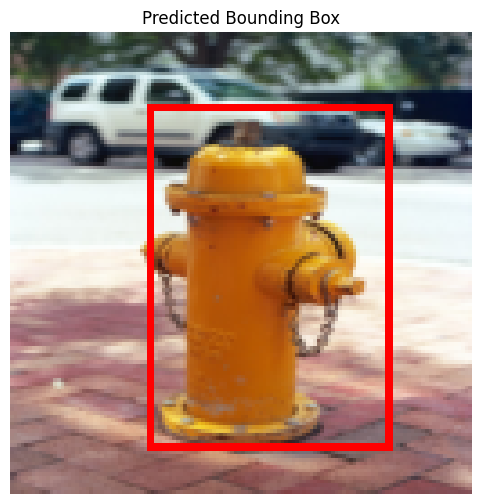

In [109]:
model.eval()

# Suppose val_dataset returns (image_tensor, gt_boxes, gt_labels)
test_image, gt_boxes, gt_labels = val_dataset[19]  # e.g., sample #19
input_tensor = test_image.unsqueeze(0).to(device)  # shape (1,3,128,128)

with torch.no_grad():
    pred_bbox, pred_class_logits = model(input_tensor)

# Convert from shape (1,4) to shape (4,)
pred_bbox = pred_bbox.squeeze(0).cpu().numpy()  # normalized [x, y, w, h] in [0,1]
pred_class_idx = torch.argmax(pred_class_logits, dim=1).item()

# Convert normalized bounding box to pixel coordinates
input_size = 128  # The image is 128x128 in your training pipeline
x, y, w, h = pred_bbox  # normalized
x1 = int(x * input_size)
y1 = int(y * input_size)
x2 = int((x + w) * input_size)
y2 = int((y + h) * input_size)

print("Predicted BBox coords (pixel):", x1, y1, x2, y2)
print("Predicted Class Index:", pred_class_idx)

# Convert test_image tensor to PIL
vis_image = TF.to_pil_image(test_image.cpu())

# Draw bounding box
draw = ImageDraw.Draw(vis_image)
draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
# draw.text((x1, y1), f"Class: {pred_class_idx}", fill="yellow")

plt.figure(figsize=(6,6))
plt.imshow(vis_image)
plt.axis("off")
plt.title("Predicted Bounding Box")
plt.show()


In [110]:
# 'vis_image' is a PIL image of shape 128x128
object_crop = vis_image.crop((x1, y1, x2, y2))
object_crop.show() 

**Depth Estimation - Using ZoeDepth**

In [111]:
# Initialize ZoeDepth
model_name = "Intel/zoedepth-nyu-kitti"
image_processor = AutoImageProcessor.from_pretrained(model_name)
model = ZoeDepthForDepthEstimation.from_pretrained(model_name)

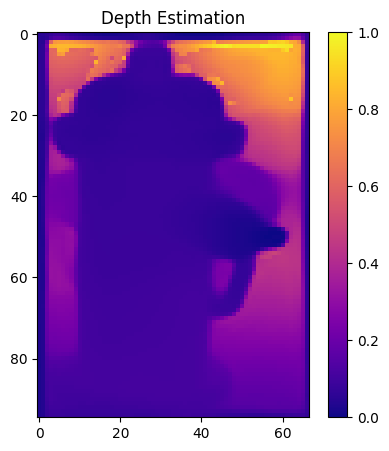

In [115]:
inputs = zoe_processor(images=object_crop, return_tensors="pt")
with torch.no_grad():
    depth_outputs = zoe_model(**inputs)

post_processed_output = zoe_processor.post_process_depth_estimation(
    depth_outputs,
    source_sizes=[(object_crop.height, object_crop.width)]
)
predicted_depth = post_processed_output[0]["predicted_depth"]

# Normalize for visualization
depth_min = predicted_depth.min()
depth_max = predicted_depth.max()
normalized_depth = (predicted_depth - depth_min) / (depth_max - depth_min + 1e-8)

depth_map = normalized_depth.squeeze().detach().cpu().numpy()

import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(depth_map, cmap='plasma')
plt.title("Depth Estimation")
plt.colorbar()
plt.show()